In [32]:
from experiment_functions import run_experiment
from pathlib import Path
import numpy as np

In [38]:
data_dir   = Path("../data/repeated_10_scale_234")
file_paths = sorted(data_dir.glob("*.graphml"))[:100] # taking a subsample of 100 datapoints to reduce running time by 10
print(f"Found {len(file_paths)} connectome files")

dt    = 0.01
sigma = 10.0
rho   = 28.0
beta  = 8 / 3

J           = 1.1
input_scale = 0.6
lambda_reg  = 3e-3
seed_base   = 42
alpha       = 0.3

t_thermalization = 10.0
t_training       = 200.0 
t_prediction     = 10.0

p_values = [0.0, 0.05, 0.1, 0.3, 0.5, 0.75, 0.9, 0.95, 0.99]
n_runs   = 4       # inner expectation over runs per reservoir
epsilon  = 1.5     # t_div threshold

Found 100 connectome files


In [39]:
results = run_experiment(
    file_paths,
    p_values          = p_values,
    n_runs            = n_runs,
    epsilon           = epsilon,
    J                 = J,
    lambda_reg        = lambda_reg,
    t_thermalization  = t_thermalization,
    t_training        = t_training,
    t_prediction      = t_prediction,
    sigma             = sigma,
    rho               = rho,
    beta              = beta,
    dt                = dt,
    input_scale       = input_scale,
    seed_base         = seed_base,
    alpha             = alpha,
    perturbation_types = ["drop_edges"],  # only edge deletion
) 

In [29]:
# save raw results so the experiment does not need to be re-run

out = {}
for p in p_values:
    out[f"drop_edges__p{p:.2f}"] = np.array(results["drop_edges"][p])
np.savez("results.npz", **out)
print("Results saved to results.npz")

Results saved to results.npz


In [30]:
def plot_experiment(results, p_values, epsilon, n_runs, n_files,
                    t_training, perturbation_types=None):
    """
    Plot E[t_div] +/- SEM vs p for a single perturbation type.
    """
    import matplotlib.pyplot as plt

    if perturbation_types is None:
        mode = "drop_edges"
    elif isinstance(perturbation_types, str):
        mode = perturbation_types
    else:
        if len(perturbation_types) != 1:
            raise ValueError(
                "This notebook version of plot_experiment only plots one perturbation type."
            )
        mode = perturbation_types[0]

    fig, ax = plt.subplots(1, 1, figsize=(12, 8), sharey=False)

    vals = [np.asarray(results[mode][p], dtype=float) for p in p_values]
    means = np.array([v.mean() if len(v) else np.nan for v in vals])
    sems = np.array([
        v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
        for v in vals
    ])

    ax.plot(p_values, means, marker="o", lw=2, color="steelblue", label="mean")
    ax.fill_between(
        p_values,
        means - sems,
        means + sems,
        alpha=0.25,
        color="steelblue",
        label=r"$\pm$ SEM",
    )
    ax.axhline(means[0], color="gray", lw=1, linestyle="--", label="baseline (p=0)")
    ax.set_title(mode.replace("_", " "), fontsize=13, fontweight="bold")
    ax.set_xlabel("perturbation p")
    ax.set_ylabel(r"$\mathbb{E}[t_{\mathrm{div}}]$ (s)")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    fig.suptitle(
        r"$\mathbb{E}_{R}\!\left[\mathbb{E}_{\mathrm{runs}}"
        r"\!\left[t_{\mathrm{div}}(f_p(R))\right]\right]$"
        f" vs perturbation $p$\n"
        f"(mode={mode}, ε={epsilon}, n_runs={n_runs}, n_files={n_files},"
        f" t_train={t_training} s)",
        fontsize=12,
    )
    fig.tight_layout()
    return fig

/var/folders/xr/pj83w7b1709ccl67bf9n4x0r0000gn/T/ipykernel_16188/2340954138.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


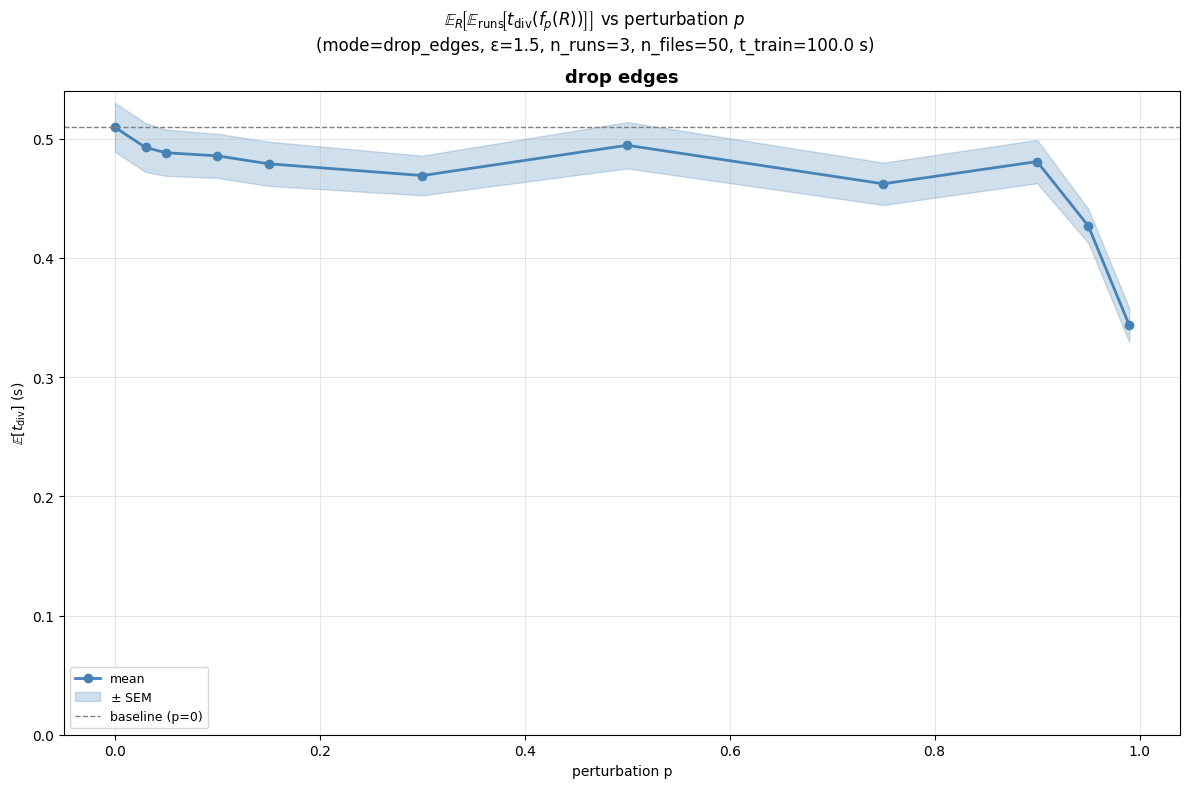

In [37]:
fig = plot_experiment(
    results,
    p_values   = p_values,
    epsilon    = epsilon,
    n_runs     = n_runs,
    n_files    = len(file_paths),
    t_training = t_training,
)
fig.savefig("experiment_results.png", dpi=150, bbox_inches="tight")
fig.show()